In [1]:
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import h5py
import numpy as np
import os
import json
import torch.nn as nn

from scipy.spatial import cKDTree
from pymbar import FES, MBAR
from typing import Optional, List, Tuple
from einops import rearrange, reduce, repeat

a_to_nm = 0.1

CENTER_OUTDIR = '/home/ethanz/data_boltz_likelihood/umbrella/chignolin' # Where to save PDBs of cluster centers.

Bad value in file PosixPath('/home/ethanz/boltz-likelihoods/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/stylelib/rotskoff_cmap.mplstyle'), line 18 ('axes.prop_cycle: cycler("color", [\'#00386b\', \'#00679f\', \'#1b9ad0\', \'#54cffb\', \'#fbac41\', \'#fa8f34\', \'#f87026\', \'#f54b1a\'])'): Key axes.prop_cycle: 'cycler("color", [\'' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)
Bad value in file PosixPath('/home/ethanz/.config/matplotlib/stylelib/rotskoff_cmap.mplstyle'), line 18 ('axes.prop_cycle: cycler("color", [\'#00386b\', \'#00679f\', \'#1b9ad0\', \'#54cffb\', \'#fbac41\', \'#fa8f34\', \'#f87026\', \'#f54b1a\'])'): Key axes.prop_cycle: 'cycler("color", [\'' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency

## Loading in RCs and plotting a GT trajectory.

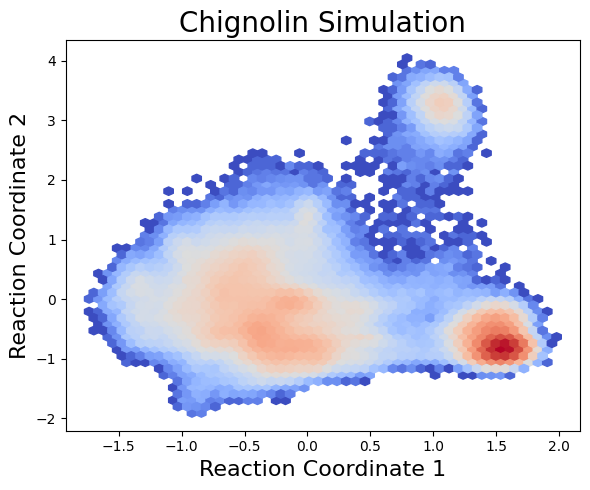

In [2]:
EIGENS_PATH = "/home/ethanz/data_boltz_likelihood/ticas/chignolin_tica_eigenvectors.npy"
MEANS_PATH = "/home/ethanz/data_boltz_likelihood/ticas/chignolin_tica_mean.npy"
GT_TOP_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin.pdb'
GT_TRAJ_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin_traj_all.hdf5'

tica_eigenvectors = np.load(EIGENS_PATH)
tica_means = np.load(MEANS_PATH)

def get_chignolin_reaction_coordinates(
    top, 
    r_coordinates,
    mean, 
    eigenvectors,
    device="cuda:0"
):
    """Computes Chignolin RC values for each frame of a trajectory.

    Parameters
    ----------
    top : mdtraj.Topology object
        Topology of the trajectory.

    r_coordinates : np.array of shape (frames, n_atoms, 3)
        Coordinate array of the trajectory.

    Returns
    -------
    all_projections_sub : torch.tensor of shape (frames, 2)
        tICA coordinate values for every frame.
    """
    traj = md.Trajectory(r_coordinates, top).atom_slice(top.select("name CA"))
    distance_indeces = [[i, j] for i in range(traj.n_atoms) 
                    for j in range(i + 1, traj.n_atoms)]
    all_distances = md.compute_distances(traj, distance_indeces)
    all_projections_sub = ((all_distances - mean)  @ eigenvectors)[:, :2]
    return torch.tensor(all_projections_sub)



gt_topology = md.load(GT_TOP_PATH).topology

with h5py.File(GT_TRAJ_PATH, 'r') as file:
    if "positions" not in file.keys():
        raise ValueError("No positions in file")
    positions = file["positions"][:]
    frames_to_save = np.arange(positions.shape[0])
    gt_trajectory = md.Trajectory(
        positions * a_to_nm, # Ground truth positions are in angstroms.
        gt_topology
    )

gt_rcs = get_chignolin_reaction_coordinates(
    gt_topology,
    gt_trajectory.xyz,
    tica_means,
    tica_eigenvectors,
)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

## Defining Umbrella Centers + Getting Starting Structures

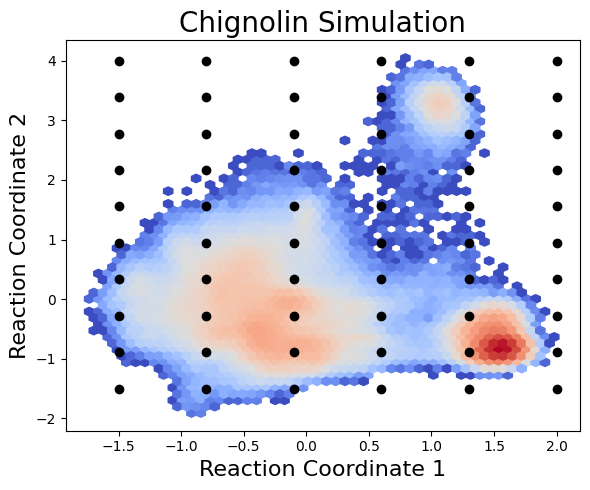

In [19]:
bottom_left = (-1.5, -1.5)
top_right = (2, 4)

num_x = 6  # Number of points in x-direction.
num_y = 10  # Number of points in y-direction.

x_vals = np.linspace(bottom_left[0], top_right[0], num_x)
y_vals = np.linspace(bottom_left[1], top_right[1], num_y)
X, Y = np.meshgrid(x_vals, y_vals)
umbrella_centers = np.stack([X.ravel(), Y.ravel()], axis=-1)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(umbrella_centers[:, 0], umbrella_centers[:, 1], color='black')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

## Saving PDBs of starting structures.

### Checking nearest structures and discarding those that are bad.

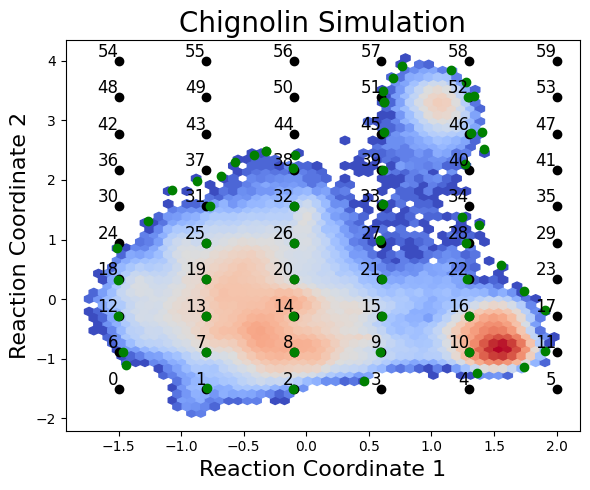

In [21]:
gt_rcs_np = gt_rcs.numpy()
tree = cKDTree(gt_rcs_np)

# Query nearest neighbor in B for each point in A
_, indices = tree.query(umbrella_centers)
closest_points = gt_rcs_np[indices]

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(umbrella_centers[:, 0], umbrella_centers[:, 1], color='black')
for i, (x, y) in enumerate(umbrella_centers):
    ax.text(x, y, str(i), fontsize=12, ha='right', va='bottom')
ax.scatter(closest_points[:, 0], closest_points[:, 1], color='green')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/global/homes/e/ethanz/data_boltz_likelihood/chignolin/ref.png'

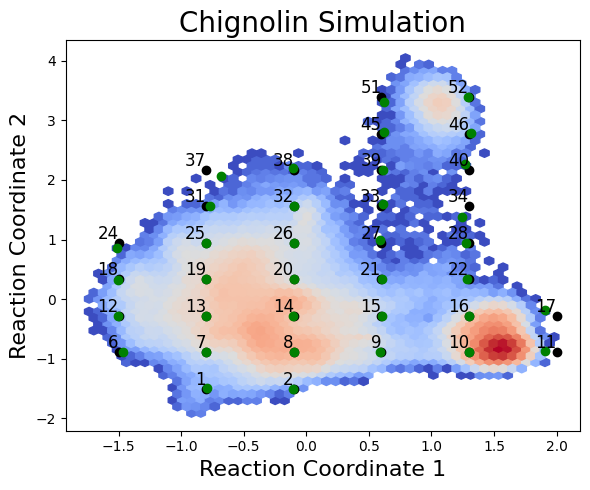

In [22]:
indices_to_discard = [0, 3, 4, 5, 23, 29, 30, 35, 36, 41, 42, 43, 44, 47, 48, 49, 50, 53, 54, 55, 56, 57, 58, 59] # Change as desired.

kept_centers = np.delete(umbrella_centers, indices_to_discard, axis=0)
kept_closest_points = np.delete(closest_points, indices_to_discard, axis=0)
kept_indices = np.delete(np.arange(0, len(indices)), indices_to_discard)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(kept_centers[:, 0], kept_centers[:, 1], color='black')
for i, (x, y) in enumerate(kept_centers):
    ax.text(x, y, kept_indices[i], fontsize=12, ha='right', va='bottom')
ax.scatter(kept_closest_points[:, 0], kept_closest_points[:, 1], color='green')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(CENTER_OUTDIR, 'ref.png'))
plt.show()

## Creating master umbrella.json dictionary.

In [ ]:
from boltz.data import const

# TODO: brittle, should 'grab' atoms using ref_atoms like pdb_to_boltz_coords does.
def pdb_to_boltz_pdb(pdb, outpath):
    ref_atoms = const.ref_atoms

    indices_to_remove = []
    prot = pdb.topology.select("protein")
    pdb = pdb.atom_slice(prot)
    pdb_seq = []

    for residue in pdb.topology.residues:
        pdb_seq.append(residue.code)

    for i, a in enumerate(list(pdb.topology.atoms)):
        atom_fullname = str(a)
        resname = atom_fullname[:3] # eg. LYS1-N
        atomname = atom_fullname[5:]
        
        if resname not in ref_atoms.keys() or atomname not in ref_atoms[resname]:
            indices_to_remove.append(i)

    all_indices = np.arange(pdb.n_atoms)
    atoms_to_keep = np.setdiff1d(all_indices, indices_to_remove)

    boltzified = pdb.atom_slice(atoms_to_keep)
    boltzified.save_pdb(outpath)

In [ ]:
indices_filtered = np.delete(indices, indices_to_discard) # gt_traj frame indices.
ks = [10 for _ in range(len(indices_filtered))] # TODO: change as desired.

master_dict = {}

for i, frame_idx in enumerate(indices_filtered):
    frame = gt_trajectory[frame_idx]
    savepath = os.path.join(CENTER_OUTDIR, f'{kept_indices[i]}.pdb')
    pdb_to_boltz_pdb(frame, savepath)
    master_dict[savepath] = {
        'k': ks[i],
        'cv0': kept_centers[i].tolist()
    }

JSON_SAVE_PATH = '/home/ethanz/boltz-likelihoods/chignolin_umbrella.json'
with open(JSON_SAVE_PATH, 'w') as file:
    json.dump(master_dict, file, indent=2)

In [ ]:
from boltz.lutils.pdb_processing import pdb_to_boltz_coords
a = pdb_to_boltz_coords(
    pdb_file='/home/ethanz/data_boltz_likelihood/umbrella/chignolin/1.pdb',
    yaml_seq='YYDPETGTWY',
    atom_mask=None,
    device='cpu'
)

Mismatched sequences for PDB /global/homes/e/ethanz/data_boltz_likelihood/umbrella/chignolin/1.pdb


## Visualizing an umbrella run.

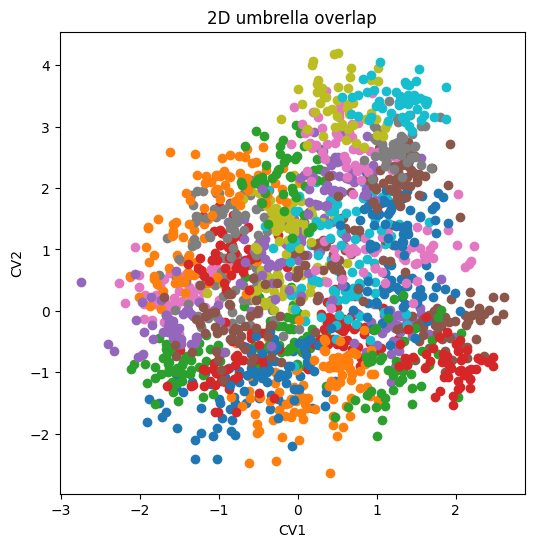

In [122]:
UMBRELLA_DIR = '/home/ethanz/boltz-likelihoods/predictions/boltz_results_chignolin_umbrella_t10_k20/umbrella'

from boltz.lutils.cvs import Chignolin
calc_cv = Chignolin(top=md.load('/home/ethanz/boltz-likelihoods/predictions/boltz_results_chignolin_multisate_1e-5_angstroms/predictions/chignolin/chignolin_model_0.pdb').topology)

all_cvs = []
for file in sorted(os.listdir(UMBRELLA_DIR)):
    cvs = []
    with h5py.File(os.path.join(UMBRELLA_DIR, file), 'r') as file:
        traj = file['traj'][:]
        for frame in traj:
            cvs.append(calc_cv(torch.tensor(frame / 10))) # Convert frame (angstroms) into units of nm.
    
    all_cvs.append(cvs)

for i in range(len(all_cvs)):
    all_cvs[i] = torch.stack(all_cvs[i], axis=0).numpy()

plt.figure(figsize=(6,6))
for traj in all_cvs:
    plt.scatter(traj[::100, 0], traj[::100, 1])

plt.xlabel("CV1")
plt.ylabel("CV2")
plt.title("2D umbrella overlap")
plt.show()

## Umbrella Calculations.

In [2]:
# Load in bias force.
bba_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_1fme.pdb") # NMR ensemble, 34 conformers.
bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA")) # Trajectory w/ 34 frames, 28 CA atoms each.
ref_ca_p = bba_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms.

helix_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/helix.pdb")
helix_ca_pdb = helix_pdb.atom_slice(helix_pdb.topology.select("name CA"))
helix_ca_p = helix_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms.

class BiasForceEnergy(nn.Module):
    def __init__(self, centers: torch.Tensor, simulation_topology: md.Topology, bias_force:int =100.0):
        # simulation topology has the number of atoms you actually expect to simulate
        # for Boltz this means everything but the hydrogens
        # all positions should be in Angstroms
        super().__init__()
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))
        self.bias_force = bias_force
        self.batch_size = centers.shape[0]
        self.reference_ca = torch.tensor(ref_ca_p, dtype=torch.float32)
        self.reference_helix_ca = torch.tensor(helix_ca_p, dtype=torch.float32)

        ca_indices = simulation_topology.select("name CA")
        alpha_indices = ca_indices[15:26]
        beta_indices = ca_indices[3:15]


        self.alpha_indices = torch.tensor(alpha_indices, dtype=torch.long)
        self.beta_indices = torch.tensor(beta_indices, dtype=torch.long)

        self.ref_beta = self.reference_ca[:, 3:15, :]
        self.ref_beta = nn.Parameter(torch.cat([self.ref_beta for _ in range(self.batch_size)], dim=0))
        self.ref_helix = self.reference_helix_ca[:, 15:26, :]
        self.ref_helix = nn.Parameter(torch.cat([self.ref_helix for _ in range(self.batch_size)], dim=0))
        self.n_atoms = simulation_topology.n_atoms


    def rmsd(self, P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
        """
        Compute RMSD per frame using Theobald's method (no explicit alignment).
        
        P: (n_frames, n_atoms, 3)
        Q: (n_frames, n_atoms, 3)

        Returns:
            rmsd_per_frame: (n_frames,)
        """
        # Center both structures
        P_centered = P - P.mean(dim=1, keepdim=True)
        Q_centered = Q - Q.mean(dim=1, keepdim=True)

        # Compute covariance matrix
        C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

        # SVD on covariance matrix
        V, S, W = torch.linalg.svd(C)
        det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
        sign_correction = det.sign()
        S_corrected = S.clone()
        S_corrected[:, -1] *= sign_correction  # fix last singular value

        dot = 2 * torch.sum(S_corrected, dim=-1)

        # Compute squared norms
        P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
        Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

        # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
        # dot = 2 * torch.sum(S, dim=-1)
        rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
        # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

        return torch.sqrt(rmsd_sq)

    def transform_a(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 2)
        return x

    def transform_b(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 1)
        return x

    def get_cv(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a = self.transform_a(self.rmsd(x[:, self.alpha_indices, :], self.ref_helix))
        b = self.transform_b(self.rmsd(x[:, self.beta_indices, :], self.ref_beta)) 
        return a, b

    def energy(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        alpha_cv, beta_cv = self.get_cv(x)

        alpha_cv = (self.centers[:, 0] - alpha_cv) ** 2
        beta_cv = (self.centers[:, 1] - beta_cv) ** 2
        energy = self.bias_force * (alpha_cv + beta_cv)
        return energy
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        # Ensure input tensor requires gradients
        if not x.requires_grad:
            x = x.clone().detach().requires_grad_(True)
        
        energy: torch.Tensor = self.energy(x)
        return energy.detach()
    
centers = torch.from_numpy(np.load('/home/ethanz/data_boltz_likelihood/bba/bba_umbrella_centers_dense_cvs.npy'))
simulation_topology = boltz_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_model_0.pdb").topology
bias_force = BiasForceEnergy(centers=centers, simulation_topology=simulation_topology, bias_force=250.0) 
# Somehow this is faster than loading the compiled one?

/tmp/ipykernel_793948/4024870967.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))


### Bias energy calculation, vectorized.

In [7]:
class BiasForceEnergyVec(nn.Module):
    def __init__(self, centers: torch.Tensor, simulation_topology: md.Topology, bias_force:int =100.0):
        """
        Notes
        -----
            - Simulation topology has the number of atoms you actually 
            expect to simulate. For Boltz, this means everything but 
            the hydrogens.
            - All positions should be in Angstroms.
        """
        print('Using vectorized version.')
        super().__init__()
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32)) # (n_centers, n_cvs)
        self.bias_force = bias_force
        self.batch_size = centers.shape[0]
 
        # Loading reference structures for CV calculations.
        bba_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_1fme.pdb") # NMR ensemble, 34 conformers.
        bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA")) # Trajectory w/ 34 frames, 28 CA atoms each.
        ref_ca_p = bba_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms.
        reference_ca = torch.tensor(ref_ca_p, dtype=torch.float32) # (1, 28, 3)
        ref_beta = reference_ca[:, 3:15, :]
        self.ref_beta = nn.Parameter(torch.cat([ref_beta for _ in range(self.batch_size)], dim=0)) # (n_centers, 12, 3)

        helix_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/helix.pdb")
        helix_ca_pdb = helix_pdb.atom_slice(helix_pdb.topology.select("name CA"))
        helix_ca_p = helix_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms.
        reference_helix_ca = torch.tensor(helix_ca_p, dtype=torch.float32) # (1, 200, 3)
        ref_helix = reference_helix_ca[:, 15:26, :]
        self.ref_helix = nn.Parameter(torch.cat([ref_helix for _ in range(self.batch_size)], dim=0)) # (n_centers, 11, 3)
        

        ca_indices = simulation_topology.select("name CA")
        alpha_indices = ca_indices[15:26]
        beta_indices = ca_indices[3:15]
        # Lists.
        self.alpha_indices = torch.tensor(alpha_indices, dtype=torch.long)
        self.beta_indices = torch.tensor(beta_indices, dtype=torch.long)

        self.n_atoms = simulation_topology.n_atoms

    def rmsd(self, P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
        """
        Compute RMSD using Theobald's method, fully vectorized.

        P, Q: (..., n_frames, n_atoms, 3)

        Returns:
            (..., n_frames)
        """

        # Center along atom dimension
        P_centered = P - P.mean(dim=-2, keepdim=True)
        Q_centered = Q - Q.mean(dim=-2, keepdim=True)

        # Covariance matrix: (..., n_frames, 3, 3)
        C = torch.matmul(
            P_centered.transpose(-2, -1),  # (..., n_frames, 3, n_atoms)
            Q_centered                     # (..., n_frames, n_atoms, 3)
        )

        # Batched SVD
        V, S, W = torch.linalg.svd(C)

        # Reflection correction
        det = torch.det(V @ W.transpose(-1, -2))
        sign_correction = det.sign()

        S_corrected = S.clone()
        S_corrected[..., -1] *= sign_correction

        dot = 2 * torch.sum(S_corrected, dim=-1)

        # Squared norms over atoms + coords
        P_norm_sq = torch.sum(P_centered ** 2, dim=(-2, -1))
        Q_norm_sq = torch.sum(Q_centered ** 2, dim=(-2, -1))

        n_atoms = P.shape[-2]

        rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / n_atoms

        return torch.sqrt(rmsd_sq)

    def transform_a(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 2)
        return x

    def transform_b(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 1)
        return x

    def get_cv(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        x : torch.Tensor of shape (n_frames, n_windows, n_atoms, 3)
        """
        a = self.transform_a(self.rmsd(x[:, :, self.alpha_indices, :], self.ref_helix))
        b = self.transform_b(self.rmsd(x[:, :, self.beta_indices, :], self.ref_beta)) 
        return a, b

    def energy(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (n_frames, n_windows, n_atoms, 3)
        alpha_cv, beta_cv = self.get_cv(x) # Each is (n_frames, n_windows)

        alpha_cv = (self.centers[:, 0].unsqueeze(0) - alpha_cv) ** 2
        beta_cv = (self.centers[:, 1].unsqueeze(0) - beta_cv) ** 2
        energy = self.bias_force * (alpha_cv + beta_cv)
        return energy # shape (n_frames, n_windows)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (n_frames, n_windows, n_atoms, 3)
        # No forces, so no gradient required.
        x.detach()
        energy: torch.Tensor = self.energy(x)
        return energy.detach()
    
centers = torch.from_numpy(np.load('/home/ethanz/data_boltz_likelihood/bba/bba_umbrella_centers_dense_cvs.npy'))
simulation_topology = boltz_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_model_0.pdb").topology
bias_force = BiasForceEnergyVec(centers=centers, simulation_topology=simulation_topology, bias_force=1000.0) 
# Somehow this is faster than loading the compiled one?

Using vectorized version.


/tmp/ipykernel_793948/1941062023.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32)) # (n_centers, n_cvs)


In [16]:
import openmm.unit as unit
from glob import glob
from tqdm import tqdm

"""Using each window's center, compute the bias potential for every 
window's trajectory. The final bias_energies tensor will be 
(num_windows, num_frames_per_window * num_windows). 
bias_energies[0, 0:num_frames_per_window] will be the bias energies 
using center 0 for the first window's trajectory, 
bias_energies[0, num_frames_per_window:num_frames_per_window * 2] 
will be the bias energies using center 0 for the second window's 
trajectory, and so forth. 
"""

stride = 1
checkpoints = glob("/data2/scratch/ethanz/boltz_results_bba_umbrella_dense_250fric_500spring/umbrella_0/cg_dataset_*.hdf5") # Simulation is saved in small segments (checkpoints).
print(len(checkpoints), "total checkpoints")
# only access hdf5 files which have a corresponding *_chk.pt file
checkpoints = [ckpt for ckpt in checkpoints if os.path.exists(ckpt.replace(".hdf5", "_chk.pt"))]
print(len(checkpoints), "valid checkpoints")

checkpoints = sorted(checkpoints, key=lambda x: int(x.split("_")[-1].split(".")[0]))
# checkpoints = checkpoints[:25] # Use for truncating trajectories if desired.

sampled_positions = []
for file in checkpoints:
    with h5py.File(file, "r") as file:
        pos_tensor = torch.tensor(file["positions"][::stride])
        sampled_positions.append(pos_tensor)

print('Position shape:', sampled_positions[0].shape) # Per checkpoint. (frames_per_checkpoint, num_windows, num_atoms, 3)
sampled_positions = torch.cat(sampled_positions, dim=0)

print("Before subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
# count the number of nonzero frames
print(f"{(sampled_positions != 0.0).all((1,2,3)).sum()} nonzero out of {sampled_positions.shape[0]}")
print(f"{(sampled_positions.isinf()).all((1,2,3)).sum()} inf out of {sampled_positions.shape[0]}")

invalid = ((sampled_positions == 0.0).all((1,2,3)) | (sampled_positions.isinf()).all((1,2,3)))
sampled_positions = sampled_positions[~invalid]
print("After removing invalid frames:", sampled_positions.shape) # (frames, windows, atoms, 3)

4 total checkpoints
3 valid checkpoints
Position shape: torch.Size([1000, 362, 250, 3])
Before subsampling: torch.Size([3000, 362, 250, 3])
3000 nonzero out of 3000
0 inf out of 3000
After removing invalid frames: torch.Size([3000, 362, 250, 3])


CV shapes: torch.Size([3000, 362]) torch.Size([3000, 362]) (362, 3000, 2)


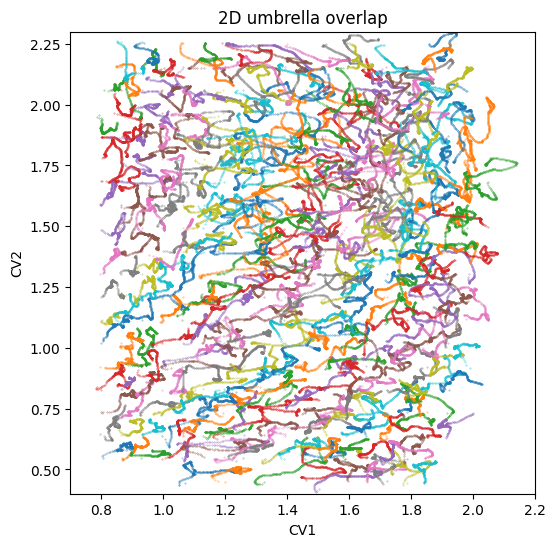

In [17]:
cvs_a, cvs_b = bias_force.get_cv(sampled_positions) # Each is (frames, windows)

all_cvs = torch.stack([cvs_a.T, cvs_b.T], dim=-1).detach().numpy() # Shape (windows, frames, 2)
print("CV shapes:", cvs_a.shape, cvs_b.shape, all_cvs.shape)

plt.figure(figsize=(6,6))
plt.xlim(0.7, 2.2)
plt.ylim(0.4, 2.3)
for traj in all_cvs:
    plt.scatter(traj[::10, 0], traj[::10, 1], s=0.1, alpha=0.7)

plt.xlabel("CV1")
plt.ylabel("CV2")
plt.title("2D umbrella overlap")
plt.show()

/tmp/ipykernel_793948/684563612.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(CMAP_BLOB)(np.linspace(0, 1, len(cv_traj)))


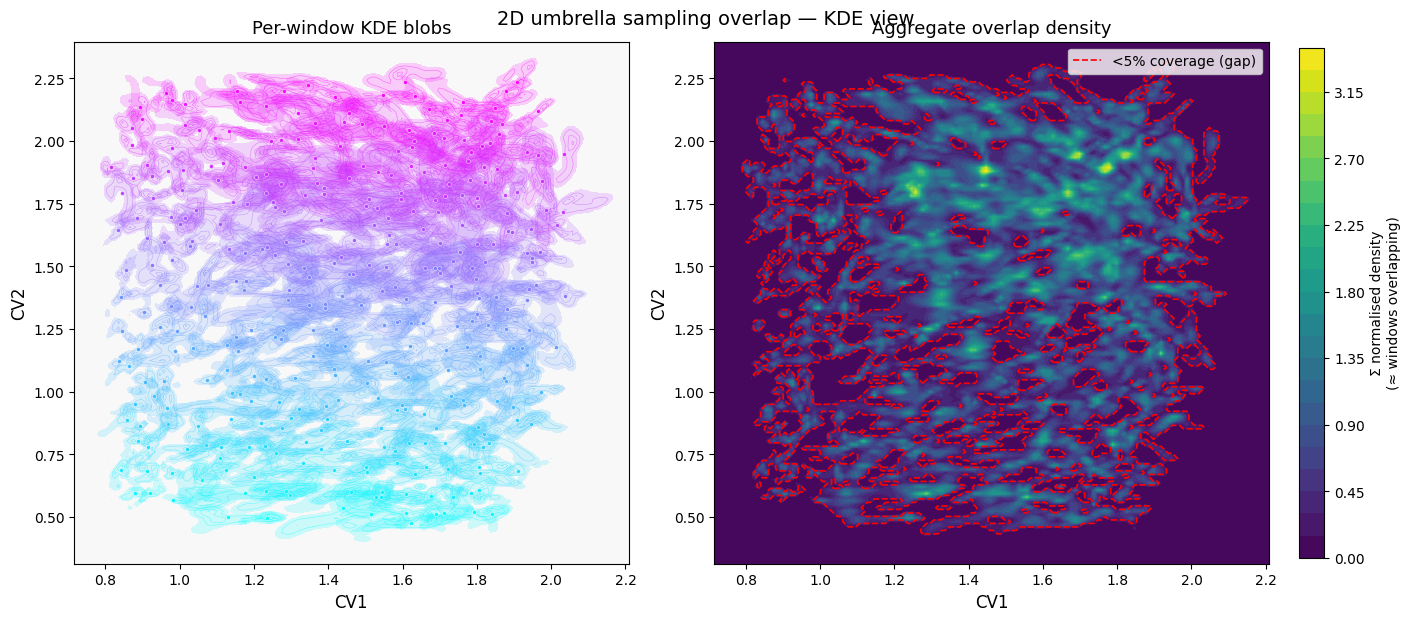

Saved: umbrella_2d_blobs.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

# ── load your data ────────────────────────────────────────────────────────────
# cv_traj shape: (362, 3000, 2)
# Replace this line with however you load your array:
#   cv_traj = np.load("cv_traj.npy")
# For demo purposes we generate synthetic data:
n_windows = 362
n_frames  = 3000
cols, rows = 19, 20
cv_traj = all_cvs

# ── settings ──────────────────────────────────────────────────────────────────
KDE_SUBSAMPLE  = 200    # frames per window used for KDE (speed vs accuracy)
KDE_GRIDPOINTS = 150    # resolution of the density grid
ALPHA_PER_WIN  = 0.18   # transparency of each window blob
CMAP_BLOB      = "cool" # colormap cycling across windows; try 'tab20', 'hsv'
SHOW_CENTERS   = True   # overlay a dot at each window's mean position
CONTOUR_LEVELS = 3      # contour lines per window (0 to disable)

# ── derived quantities ────────────────────────────────────────────────────────
all_cv1 = cv_traj[:, :, 0].ravel()
all_cv2 = cv_traj[:, :, 1].ravel()
pad1 = (all_cv1.max() - all_cv1.min()) * 0.05
pad2 = (all_cv2.max() - all_cv2.min()) * 0.05
x_min, x_max = all_cv1.min() - pad1, all_cv1.max() + pad1
y_min, y_max = all_cv2.min() - pad2, all_cv2.max() + pad2

xi = np.linspace(x_min, x_max, KDE_GRIDPOINTS)
yi = np.linspace(y_min, y_max, KDE_GRIDPOINTS)
XX, YY = np.meshgrid(xi, yi)
grid_pts = np.vstack([XX.ravel(), YY.ravel()])

colors = plt.cm.get_cmap(CMAP_BLOB)(np.linspace(0, 1, len(cv_traj)))

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# ── LEFT: individual window KDE blobs ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#f8f8f8")

for wi, (traj, col) in enumerate(zip(cv_traj, colors)):
    pts = traj[::max(1, n_frames // KDE_SUBSAMPLE)]  # subsample for speed
    if pts.shape[0] < 4:
        continue
    try:
        kde = gaussian_kde(pts.T, bw_method=0.3)
        Z = kde(grid_pts).reshape(XX.shape)
        Z /= Z.max()  # normalise so all windows are equally visible

        # filled contour at low threshold → blob shape
        ax.contourf(XX, YY, Z, levels=[0.05, 1.0],
                    colors=[col], alpha=ALPHA_PER_WIN)

        if CONTOUR_LEVELS > 0:
            levels = np.linspace(0.2, 0.9, CONTOUR_LEVELS)
            ax.contour(XX, YY, Z, levels=levels,
                       colors=[col], alpha=0.5, linewidths=0.4)
    except np.linalg.LinAlgError:
        pass  # singular matrix → skip this window

    if SHOW_CENTERS:
        ax.scatter(*pts.mean(axis=0), color=col, s=8, zorder=5,
                   edgecolors="white", linewidths=0.3)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("CV1", fontsize=12)
ax.set_ylabel("CV2", fontsize=12)
ax.set_title("Per-window KDE blobs", fontsize=13)

# ── RIGHT: aggregate density (how many windows visited each point) ─────────────
ax2 = axes[1]

# sum normalised KDEs → counts how many windows overlap at each grid point
density_sum = np.zeros(XX.shape)
for wi, traj in enumerate(cv_traj):
    pts = traj[::max(1, n_frames // KDE_SUBSAMPLE)]
    if pts.shape[0] < 4:
        continue
    try:
        kde = gaussian_kde(pts.T, bw_method=0.3)
        Z = kde(grid_pts).reshape(XX.shape)
        Z /= Z.max()
        density_sum += Z
    except np.linalg.LinAlgError:
        pass

im = ax2.contourf(XX, YY, density_sum, levels=30, cmap="viridis")
cb = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cb.set_label("Σ normalised density\n(≈ windows overlapping)", fontsize=10)

# mark any gaps (low coverage)
gap_mask = density_sum < density_sum.max() * 0.05
if gap_mask.any():
    ax2.contour(XX, YY, gap_mask.astype(float), levels=[0.5],
                colors="red", linewidths=1.2, linestyles="--")
    ax2.plot([], [], "r--", linewidth=1.2, label="<5% coverage (gap)")
    ax2.legend(fontsize=10, loc="upper right")

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xlabel("CV1", fontsize=12)
ax2.set_ylabel("CV2", fontsize=12)
ax2.set_title("Aggregate overlap density", fontsize=13)

plt.suptitle("2D umbrella sampling overlap — KDE view", fontsize=14, y=1.01)
plt.savefig("umbrella_2d_blobs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: umbrella_2d_blobs.png")

In [19]:
n_frames, n_windows, n_atoms, _ = sampled_positions.shape

# BiasForceBBA expects position tensor of shape (num_windows, atoms, 3).
positions_flattened = sampled_positions.permute(1, 0, 2, 3).reshape(n_windows * n_frames, n_atoms, 3)
positions_repeated = positions_flattened.unsqueeze(1).expand(-1, n_windows, -1, -1)

# cv_values_all_frames = torch.concat(
#     [torch.stack(tup_elem) for tup_elem in [
#         bias_force.get_cv(all_window_frame) for all_window_frame in sampled_positions
#     ]], dim=1
# ).detach().permute(1, 0).numpy() # (n_total_frames, dim)

block_size = 100
bias_energies = []

for i in tqdm(range(0, len(positions_repeated), block_size)):
    block = positions_repeated[i:i + block_size]  # (block_size, windows, atoms, 3)
    block_tensor = torch.stack(list(block))        # if positions_repeated yields tensors
    bias_energies.append(bias_force(block_tensor)) # (block_size, windows)

bias_energies = torch.cat(bias_energies, dim=0).detach().numpy().T  # (windows, windows * frames)

# TODO: change as appropriate based on chosen simulation energy units and such. 
sim_energy_unit = unit.kilocalorie_per_mole 
sim_temp = 350
sim_temp_unit = unit.kelvin

bias_energies *= sim_energy_unit / (sim_temp_unit * sim_temp * unit.constants.BOLTZMANN_CONSTANT_kB * unit.AVOGADRO_CONSTANT_NA).in_units_of(sim_energy_unit)
# bias_energies are now in units of kT
N_k = np.array([n_frames for _ in range(n_windows)])

100%|██████████| 10860/10860 [29:23<00:00,  6.16it/s]


In [61]:
plt.hist(bias_energies.flatten())
plt.xlabel('Bias Energy (kT)')
plt.ylabel('Frequency')
plt.show()

[[5.58629245e-06 7.91110322e-02 1.29900202e-01 ... 1.13737500e+03
  1.13737317e+03 1.13748901e+03]
 [5.99092054e+00 7.09301186e+00 7.51008368e+00 ... 1.06608850e+03
  1.06609583e+03 1.06624011e+03]
 [2.34312496e+01 2.54932270e+01 2.62612247e+01 ... 1.01432166e+03
  1.01433807e+03 1.01451111e+03]
 ...
 [1.31396252e+03 1.33228870e+03 1.33657495e+03 ... 2.33307419e+01
  2.33131161e+01 2.32416039e+01]
 [1.39322693e+03 1.41270178e+03 1.41739990e+03 ... 1.59922609e+01
  1.59848404e+01 1.59453869e+01]
 [1.42962122e+03 1.44958203e+03 1.45445740e+03 ... 1.71867180e+01
  1.71838608e+01 1.71589088e+01]]


KeyboardInterrupt: 

In [48]:
from matplotlib.collections import RegularPolyCollection
from matplotlib.patches import RegularPolygon
import matplotlib.colors as mcolors
import scipy


hexbin_centers = np.load('/home/ethanz/boltz-likelihoods/hexes.npy')
print(hexbin_centers.shape)

fes = FES(bias_energies, N_k)

# Why is the first parameter all zeros?
# Seems like it is for if you want to compute the FES with a given bias potential.

fes.generate_fes(np.zeros(n_frames * n_windows), all_cvs, fes_type="kde", kde_parameters={'bandwidth': 0.1})
# fes.generate_fes(np.zeros(all_frames.shape[0]), all_frames, fes_type="histogram", histogram_parameters={"bin_edges": [x_edges, y_edges]})
results = fes.get_fes(hexbin_centers, uncertainty_method=None)
f = results["f_i"]
f = f - f.min()

plt.figure(figsize=(6,5))
sc = plt.scatter(hexbin_centers[:, 0], hexbin_centers[:, 1], c=f, s=200, alpha=0.1, edgecolor='k', cmap='coolwarm_r', vmax=40)
plt.colorbar(sc, label="value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hexbin centers with values")
plt.show()

plt.hist(f)
plt.show()

# plt.figure(figsize=(6, 5))
# ax = plt.gca()

# hb = ax.hexbin(hexbin_centers[:,0], hexbin_centers[:,1], C=f, gridsize=50, cmap='coolwarm_r')
# ax.set_title("Chignolin Simulation", fontsize=20)
# ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
# ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
# plt.tight_layout()
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/ethanz/boltz-likelihoods/hexes.npy'

In [52]:
all_cvs.shape

(362, 500, 2)

Failed to reach a solution to within tolerance with hybr: trying next method


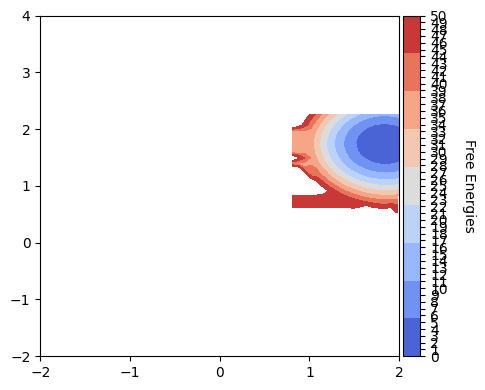

In [62]:
import matplotlib.ticker as ticker
all_cvs = all_cvs.reshape(-1, 2)

_, x_edges, y_edges = np.histogram2d(all_cvs[:, 0], all_cvs[:, 1], bins=20)
bin_centers_0 = 0.5 * (x_edges[:-1] + x_edges[1:])
bin_centers_1 = 0.5 * (y_edges[:-1] + y_edges[1:])
bin_centers = np.array(np.meshgrid(bin_centers_0, bin_centers_1)).T.reshape(-1, 2)
free_energy = np.inf * np.ones(bin_centers.shape[0])

center_indices_to_use = []
centers_to_use = []

width_0 = bin_centers_0[1] - bin_centers_0[0]
width_1 = bin_centers_1[1] - bin_centers_1[0]

for i in range(bin_centers.shape[0]):
    bin_center = bin_centers[i]
    x0, x1 = bin_center[0] - width_0 / 2, bin_center[0] + width_0 / 2
    y0, y1 = bin_center[1] - width_1 / 2, bin_center[1] + width_1 / 2
    
    mask = (all_cvs[:, 0] >= x0) & (all_cvs[:, 0] < x1) & (all_cvs[:, 1] >= y0) & (all_cvs[:, 1] < y1)
    num_points = np.sum(mask)
    if num_points > 0:
        centers_to_use.append(bin_center)
        center_indices_to_use.append(i)
centers_to_use = np.array(centers_to_use)
center_indices_to_use = np.array(center_indices_to_use)


fes = FES(bias_energies, N_k)
# TODO: how did we compute bandwidth?
fes.generate_fes(np.zeros(all_cvs.shape[0]), all_cvs, fes_type="kde", kde_parameters={'bandwidth': 0.09058443312209644})
# fes.generate_fes(np.zeros(all_frames.shape[0]), all_frames, fes_type="histogram", histogram_parameters={"bin_edges": [x_edges, y_edges]})
results = fes.get_fes(centers_to_use, uncertainty_method=None)
f = results["f_i"] # (36, )
f = f - f.min()
free_energy[center_indices_to_use] = f

plt.figure(figsize=(5, 4))
vmax = 50
plt.contourf(bin_centers_0, bin_centers_1, free_energy.reshape(len(bin_centers_0), len(bin_centers_1)).T,
                levels=np.linspace(0, vmax, 10), cmap='coolwarm')
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, 10), pad=0.01)
cbar.set_label('Free Energies', rotation=270, labelpad=20)



# only label integer values
cbar.set_ticks(np.arange(0, vmax + 1, 1))
# # plt.scatter(centers[:, 0], centers[:, 1], color='black', s=10, marker="x", label="Centers")
# plt.scatter(starting_tica[:, 0], starting_tica[:, 1], color='red', s=10)
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# make X and Y axis ticks every 0.5
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1.0))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1.0))


# plt.xlabel(r"$\textrm{Native Contacts}$")
# plt.ylabel(r"$\textrm{Dihedral}$")
plt.xlim(-2, 2)
plt.ylim(-2, 4)
plt.tight_layout()
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

In [49]:
import scipy
kde = scipy.stats.gaussian_kde(cv_values_all_frames.T)
kde.factor

0.09058443312209644

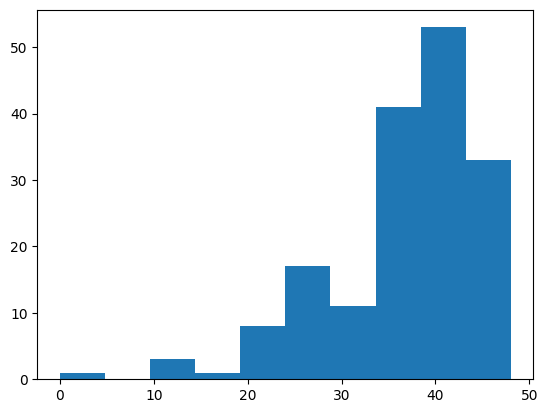

In [100]:
plt.hist(f)
plt.show()

In [63]:
a = np.histogram2d(all_frames[0, :], all_frames[1, :], bins=36)
_, x_edges, y_edges = a

### MBAR Reweighting.

In [68]:
import openmm.unit as unit
STRIDE = 100

bias_energies = []
all_cvs = []
for file in sorted(os.listdir(UMBRELLA_DIR)):
    cvs = []
    with h5py.File(os.path.join(UMBRELLA_DIR, file), 'r') as file:
        biases = file['u_bias'][:]
        if len(biases) == 2000:
            bias_energies.append(biases[::STRIDE])
        traj = file['traj'][:]
        if len(traj) == 2000:
            for frame in traj[::STRIDE]:
                cvs.append(calc_cv(torch.tensor(frame / 10))) # Convert frame (angstroms) into units of nm.
    
    if len(cvs) != 0:
        all_cvs.append(np.array(cvs))

coords = np.stack(all_cvs)
bias_energies = np.stack(bias_energies)
bias_energies = bias_energies * (unit.kilojoules_per_mole) / (unit.kelvin * 50 * (unit.BOLTZMANN_CONSTANT_kB * unit.AVOGADRO_CONSTANT_NA).in_units_of(unit.kilojoule_per_mole / unit.kelvin))
print(bias_energies.shape, coords.shape)

(15, 20) (15, 20, 2)


In [ ]:
target_shape = (15, 300)
bias_energies_padded = np.zeros(target_shape, dtype=bias_energies.dtype)

# copy the original data into the slice
bias_energies_padded[:, :bias_energies.shape[1]] = bias_energies

N_k = np.array([20 for _ in range(15)])
fes = FES(bias_energies_padded, N_k)


_, x_edges, y_edges = np.histogram2d(reindexed_tica[:, 0], reindexed_tica[:, 1], bins=15)

fes.generate_fes(np.zeros(reindexed_tica.shape[0]), reindexed_tica, fes_type="histogram", histogram_parameters={"bin_edges": [x_edges, y_edges]})


IndexError: index 20 is out of bounds for axis 0 with size 20

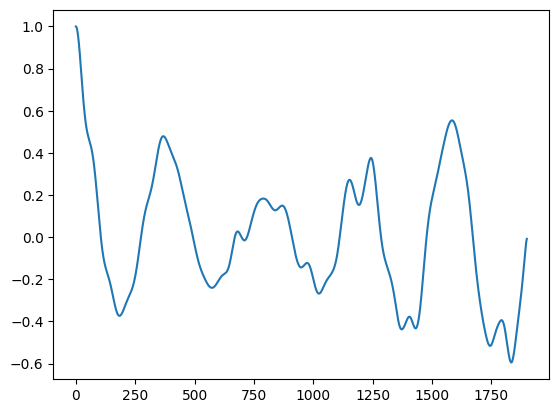

In [38]:
def acf(x, length=1900):
    return  np.array([1]+[np.corrcoef(x[:-i], x[i:])[0,1]  \
        for i in range(1, length)])

a = acf(bias_energies[0])

plt.plot(a)
plt.show()